1. Train a simple neural network using Keras on the Fashion MNIST dataset and plot both training loss and validation loss for each epoch using matplotlib.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    verbose=1
)

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8258 - loss: 0.4930 - val_accuracy: 0.8444 - val_loss: 0.4323
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8659 - loss: 0.3710 - val_accuracy: 0.8555 - val_loss: 0.3944
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8790 - loss: 0.3345 - val_accuracy: 0.8610 - val_loss: 0.3775
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8865 - loss: 0.3108 - val_accuracy: 0.8587 - val_loss: 0.3824
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8918 - loss: 0.2947 - val_accuracy: 0.8783 - val_loss: 0.3406
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8979 - loss: 0.2789 - val_accuracy: 0.8662 - val_loss: 0.3550
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9008 - loss: 0.2676 - val_accuracy: 0.8801 - val_loss: 0.3419
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9039 - loss: 0.2570 - 

2. Intentionally overfit a small neural network on a subset of the Fashion MNIST data (e.g., only 500 samples) and describe two signs from your loss curves that indicate overfitting.<br><br><em><strong>Hint:</strong> Look for divergence between training and validation loss after a certain number of epochs.</em>


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_small = x_train[:500]
y_small = y_train[:500]

model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_small,
    y_small,
    epochs=30,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.4600 - loss: 1.6251 - val_accuracy: 0.5701 - val_loss: 1.1294
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.6840 - loss: 0.8884 - val_accuracy: 0.6580 - val_loss: 0.9458
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.7460 - loss: 0.7252 - val_accuracy: 0.7036 - val_loss: 0.8775
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8120 - loss: 0.5376 - val_accuracy: 0.7419 - val_loss: 0.7268
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.8600 - loss: 0.4902 - val_accuracy: 0.7344 - val_loss: 0.7356
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8500 - loss: 0.4525 - val_accuracy: 0.7215 - val_loss: 0.7698
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.8660 - loss: 0.4077 - val_accuracy: 0.7698 - val_loss: 0.6789
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.8980 - loss: 0.3301 - val_accuracy: 0.7749 

3. Add an EarlyStopping callback to your Keras model training so that it stops if validation loss does not improve for 3 consecutive epochs, and report after how many epochs the training stopped.


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train,
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("Training stopped after epochs:", len(history.history['loss']))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8236 - loss: 0.4989 - val_accuracy: 0.8536 - val_loss: 0.4126
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8654 - loss: 0.3761 - val_accuracy: 0.8648 - val_loss: 0.3859
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8771 - loss: 0.3380 - val_accuracy: 0.8679 - val_loss: 0.3702
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8849 - loss: 0.3140 - val_accuracy: 0.8603 - val_loss: 0.3982
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8902 - loss: 0.2976 - val_accuracy: 0.8659 - val_loss: 0.3869
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8966 - loss: 0.2812 - val_accuracy: 0.8793 - val_loss: 0.3368
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9009 - loss: 0.2682 - val_accuracy: 0.8749 - val_loss: 0.3416
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9033 - loss: 0.2583 -

4. After training your Fashion MNIST model, calculate and print the accuracy, precision, and recall for the test set using scikit-learn's metrics functions.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_prob = model.predict(x_test)

y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average='weighted')

recall = recall_score(y_test, y_pred, average='weighted')

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8793
Precision: 0.8815950810998664
Recall: 0.8793


5. Compute and plot the ROC curve and AUC score for your model's predictions on the Fashion MNIST test set using scikit-learn.<br><br><em><strong>Hint:</strong> For multiclass, use the 'roc_auc_score' function with 'multi_class' parameter set to 'ovr'.</em>

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Multiclass ROC-AUC (OVR): 0.9900852499999999


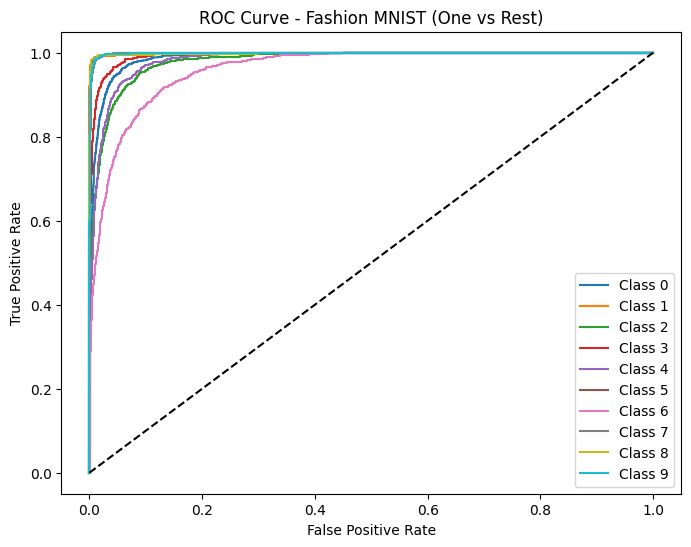

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

y_prob = model.predict(x_test)

y_test_bin = label_binarize(y_test, classes=np.arange(10))

auc_score = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')

print("Multiclass ROC-AUC (OVR):", auc_score)

plt.figure(figsize=(8, 6))

for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0, 1], [0, 1], "k--")  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fashion MNIST (One vs Rest)")
plt.legend()
plt.show()